# LunarLander DQN

## 实验目标

本实验使用 `DQN` 训练 LunarLander 的离散动作策略。目标是让智能体学会在重力作用下稳定控制着陆器，逐步减速、修正横向位置和姿态，并尽可能平稳地落在指定着陆区域。这里的重点不仅是把训练跑起来，还要把 `DQN` 这条经典深度强化学习路线讲清楚。

## 为什么这里选择 DQN

LunarLander 的动作空间是离散的，这使它成为 `DQN` 的经典适用环境之一。相比 `PPO`，`DQN` 更适合在这里承担“经典深度价值学习方法”展示角色，因为它能够直观体现：

- 如何用神经网络近似 Q 函数
- 如何使用经验回放打散样本相关性
- 如何使用目标网络缓解训练不稳定

因此，`15` 的重点是保留这条经典路线，而不是完全被更现代的 `PPO` 覆盖。

## 收敛判断方式

这个 notebook 不会空泛地宣称“保证收敛”，而是通过一组具体指标判断训练是否进入稳定阶段：

- 训练过程中的 episode return 是否持续改善
- 最近完成回合的平均回报是否逐步提升
- 最近成功着陆率是否明显高于随机基线
- 训练后固定评估阶段的平均回报和成功率是否达到稳定水平

只有这些信号同时变好，才说明策略不仅在学习，而且确实学到了有意义的控制行为。

## 设备与并行说明

- 优先自动选择 `CUDA`
- 如果没有 `CUDA`，则尝试 `MPS`
- 都不可用时回退到 `CPU`
- 本实验不强行引入并行环境，因为 DQN 的主瓶颈不完全在网络前向与反向，更核心的是交互、经验回放和目标网络更新

也就是说，这里不会为了统一形式而硬写多进程。

In [1]:
import random
from collections import deque, namedtuple
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm

In [2]:
ENV_ID = "LunarLander-v3"
NUM_EPISODES = 1200
MAX_STEPS = 1000
BATCH_SIZE = 128
GAMMA = 0.99
LEARNING_RATE = 1e-3
REPLAY_BUFFER_SIZE = 100000
MIN_REPLAY_SIZE = 5000
TARGET_UPDATE_INTERVAL = 1000
TRAIN_FREQUENCY = 4
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
EVAL_EPISODES = 100
DEMO_EPISODES = 3
DEMO_FPS = 30
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

## 参数选择说明

这里的参数选择是偏稳的一版默认设置，重点是给 LunarLander 这样的中等复杂离散控制任务提供较平衡的训练预算：

- `NUM_EPISODES = 1200`：给 DQN 足够的交互预算，避免只学到非常初级的控制行为
- `BATCH_SIZE = 128`：在 replay buffer 足够大后，用中等 batch 做稳定更新
- `LEARNING_RATE = 1e-3`：作为 DQN 在这类任务上的常见起点
- `MIN_REPLAY_SIZE = 5000`：先积累一定经验再开始训练，减少初期更新噪声
- `TARGET_UPDATE_INTERVAL = 1000`：定期同步目标网络，缓解自举更新不稳定问题
- `EPSILON_DECAY = 0.995`：逐渐从探索过渡到利用，但不让探索过早消失
- `DEMO_EPISODES = 3`：训练后录制 3 个不同初始化 seed 的策略回放，直接展示着陆效果

如果后续训练曲线仍明显不稳，优先调整的方向通常是：

- 提高 `NUM_EPISODES`
- 降低学习率
- 放慢 epsilon 衰减
- 提高 replay buffer 预热规模

In [3]:
env = gym.make(ENV_ID)
obs_dim = int(np.prod(env.observation_space.shape))
action_dim = env.action_space.n
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


In [4]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x):
        return self.net(x)


policy_net = QNetwork(obs_dim, action_dim).to(DEVICE)
target_net = QNetwork(obs_dim, action_dim).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = torch.optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)

In [5]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    with torch.no_grad():
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        q_values = policy_net(state_tensor)
        return int(torch.argmax(q_values, dim=-1).item())


def optimize_model():
    if len(replay_buffer) < max(MIN_REPLAY_SIZE, BATCH_SIZE):
        return None

    transitions = random.sample(replay_buffer, BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    state_batch = torch.tensor(np.array(batch.state), dtype=torch.float32, device=DEVICE)
    action_batch = torch.tensor(batch.action, dtype=torch.long, device=DEVICE).unsqueeze(-1)
    reward_batch = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE)
    next_state_batch = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=DEVICE)
    done_batch = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE)

    current_q = policy_net(state_batch).gather(1, action_batch).squeeze(-1)
    with torch.no_grad():
        next_q = target_net(next_state_batch).max(dim=1).values
        target_q = reward_batch + GAMMA * next_q * (1 - done_batch)

    loss = nn.functional.smooth_l1_loss(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
    optimizer.step()
    return float(loss.detach().cpu())

In [6]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

epsilon = EPSILON_START
global_step = 0
episode_returns = []
episode_successes = []
recent_returns = []
recent_successes = []
loss_history = []

progress_bar = tqdm(range(NUM_EPISODES), desc="DQN episodes")

for episode in progress_bar:
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.append(Transition(state, action, reward, next_state, float(done)))
        total_reward += reward
        state = next_state
        global_step += 1

        if global_step % TRAIN_FREQUENCY == 0:
            loss_value = optimize_model()
            if loss_value is not None:
                loss_history.append(loss_value)

        if global_step % TARGET_UPDATE_INTERVAL == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if done:
            break

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    success_value = float(total_reward >= 200)
    episode_returns.append(total_reward)
    episode_successes.append(success_value)
    recent_returns.append(total_reward)
    recent_successes.append(success_value)
    if len(recent_returns) > 50:
        recent_returns.pop(0)
    if len(recent_successes) > 50:
        recent_successes.pop(0)

    if episode % 10 == 0 or episode == NUM_EPISODES - 1:
        progress_bar.set_postfix(
            recent_return=f"{np.mean(recent_returns):.1f}",
            success=f"{np.mean(recent_successes):.2f}",
            epsilon=f"{epsilon:.2f}",
        )

env.close()

DQN episodes: 100%|██████████| 1200/1200 [12:13<00:00,  1.64it/s, epsilon=0.05, recent_return=186.3, success=0.64]


In [7]:
episode_return_series = pd.Series(episode_returns, dtype=float)
episode_success_series = pd.Series(episode_successes, dtype=float)
loss_series = pd.Series(loss_history, dtype=float)

rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_success = episode_success_series.rolling(50).mean() if len(episode_success_series) >= 50 else episode_success_series
rolling_loss = loss_series.rolling(100).mean() if len(loss_series) >= 100 else loss_series

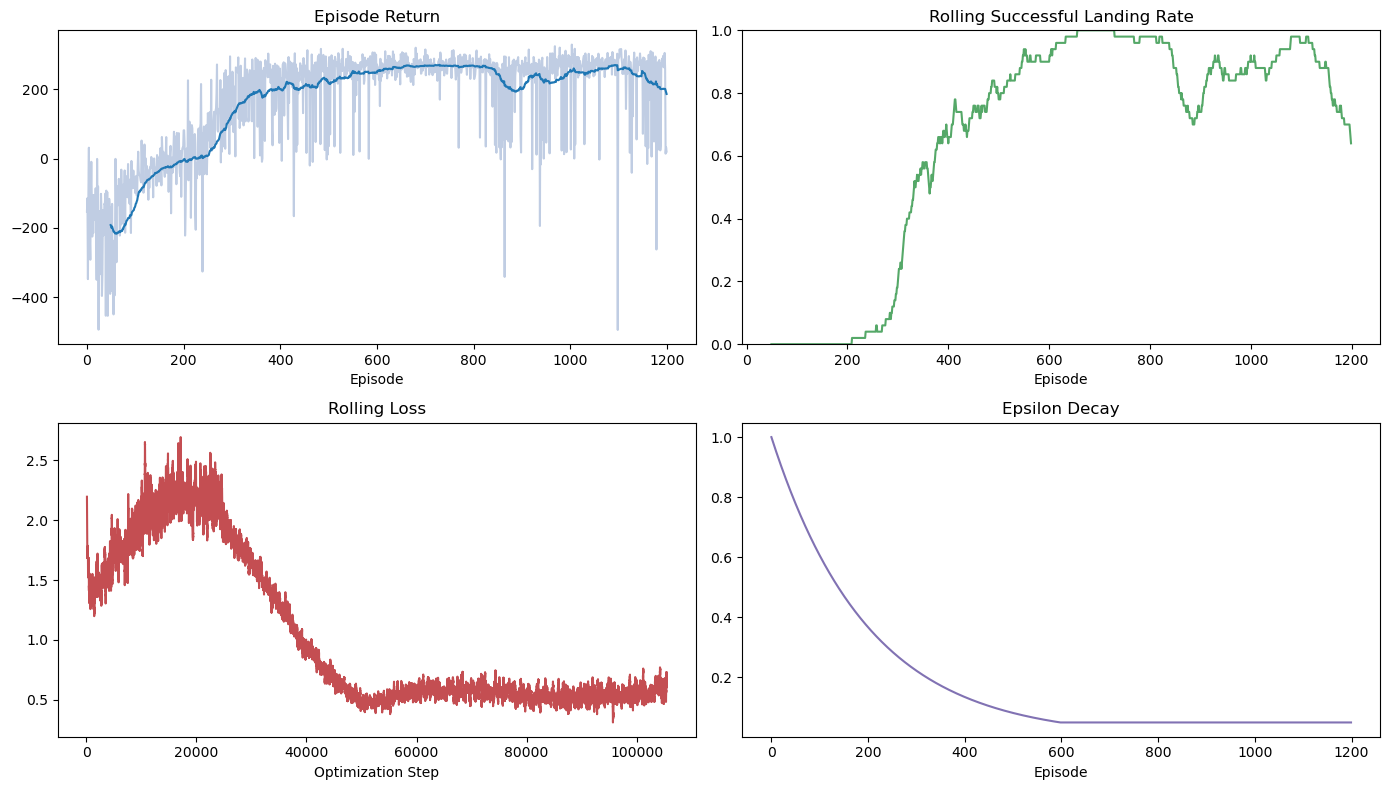

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(episode_returns, alpha=0.35, color="#4c72b0")
axes[0, 0].plot(rolling_return, color="#1f77b4")
axes[0, 0].set_title("Episode Return")
axes[0, 0].set_xlabel("Episode")

axes[0, 1].plot(rolling_success, color="#55a868")
axes[0, 1].set_title("Rolling Successful Landing Rate")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylim(0, 1)

axes[1, 0].plot(rolling_loss, color="#c44e52")
axes[1, 0].set_title("Rolling Loss")
axes[1, 0].set_xlabel("Optimization Step")

epsilon_curve = [max(EPSILON_END, EPSILON_START * (EPSILON_DECAY ** i)) for i in range(NUM_EPISODES)]
axes[1, 1].plot(epsilon_curve, color="#8172b3")
axes[1, 1].set_title("Epsilon Decay")
axes[1, 1].set_xlabel("Episode")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dqn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
eval_env = gym.make(ENV_ID)
eval_returns = []
eval_successes = []

for episode in tqdm(range(EVAL_EPISODES), desc="Policy evaluation"):
    state, info = eval_env.reset(seed=SEED + 10000 + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            action = int(torch.argmax(policy_net(state_tensor), dim=-1).item())
        state, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    eval_returns.append(total_reward)
    eval_successes.append(int(total_reward >= 200))

eval_env.close()

Policy evaluation: 100%|██████████| 100/100 [00:22<00:00,  4.35it/s]


In [10]:
eval_avg_return = float(np.mean(eval_returns))
eval_return_std = float(np.std(eval_returns))
eval_success_rate = float(np.mean(eval_successes))

metrics = pd.DataFrame(
    {
        "metric": [
            "device",
            "num_episodes",
            "recent_episode_return_last_50",
            "recent_success_rate_last_50",
            "evaluation_average_return",
            "evaluation_return_std",
            "evaluation_success_rate",
        ],
        "value": [
            str(DEVICE),
            NUM_EPISODES,
            float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0,
            float(episode_success_series.tail(50).mean()) if len(episode_success_series) > 0 else 0.0,
            eval_avg_return,
            eval_return_std,
            eval_success_rate,
        ],
    }
)
metrics

,metric,value
0,device,mps
1,num_episodes,1200
2,recent_episode_return_last_50,186.319692
3,recent_success_rate_last_50,0.64
4,evaluation_average_return,236.873721
5,evaluation_return_std,81.863206
6,evaluation_success_rate,0.74


In [11]:
demo_summaries = []
for demo_idx in range(DEMO_EPISODES):
    demo_env = gym.make(ENV_ID, render_mode="rgb_array")
    state, info = demo_env.reset(seed=SEED + 20000 + demo_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = demo_env.render()
        if frame is not None:
            frames.append(frame)

        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            action = int(torch.argmax(policy_net(state_tensor), dim=-1).item())

        state, reward, terminated, truncated, info = demo_env.step(action)
        total_reward += reward

        if terminated or truncated:
            final_frame = demo_env.render()
            if final_frame is not None:
                frames.append(final_frame)
            demo_summaries.append(
                {
                    "demo_index": demo_idx,
                    "seed": SEED + 20000 + demo_idx,
                    "total_reward": total_reward,
                    "steps": step + 1,
                    "successful_landing": int(total_reward >= 200),
                }
            )
            break

    demo_env.close()
    if frames:
        imageio.mimsave(RESULTS_DIR / f"dqn_demo_{demo_idx + 1}.gif", frames, fps=DEMO_FPS)

metrics.to_csv(RESULTS_DIR / "dqn_metrics.csv", index=False)
pd.DataFrame({"episode_return": episode_returns}).to_csv(RESULTS_DIR / "dqn_episode_returns.csv", index=False)
pd.DataFrame({"episode_success": episode_successes}).to_csv(RESULTS_DIR / "dqn_episode_successes.csv", index=False)
pd.DataFrame({"eval_return": eval_returns, "eval_success": eval_successes}).to_csv(RESULTS_DIR / "dqn_eval_results.csv", index=False)
pd.DataFrame(demo_summaries).to_csv(RESULTS_DIR / "dqn_demo_summary.csv", index=False)

print(f"Device: {DEVICE}")
print(f"Recent episode return (last 50): {episode_return_series.tail(50).mean() if len(episode_return_series) > 0 else 0.0:.2f}")
print(f"Recent success rate (last 50): {episode_success_series.tail(50).mean() if len(episode_success_series) > 0 else 0.0:.4f}")
print(f"Evaluation average return: {eval_avg_return:.2f}")
print(f"Evaluation return std: {eval_return_std:.2f}")
print(f"Evaluation success rate: {eval_success_rate:.4f}")
print("Saved 3 DQN landing demo GIFs with different initialization seeds.")
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Device: mps
Recent episode return (last 50): 186.32
Recent success rate (last 50): 0.6400
Evaluation average return: 236.87
Evaluation return std: 81.86
Evaluation success rate: 0.7400
Saved 3 DQN landing demo GIFs with different initialization seeds.
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/15-lunarlander-dqn/results


## 结果解读

这个实验是否收敛，不能只看单个 episode 的 reward。更重要的是结合下面这些信号一起看：

- `Episode Return` 的滚动均值是否持续改善
- `Rolling Successful Landing Rate` 是否明显高于随机基线
- `Rolling Loss` 是否在训练中逐渐稳定
- 固定评估阶段的平均回报和成功率是否稳定

如果这些指标同时变好，才说明 DQN 不只是短期碰运气，而是真的学会了更稳定的着陆控制行为。